# Classfication Track : BCI Motor Imagery

This notebook contains the classification pipeline for classifying 4 motor imagery tasks - left hand, right hand, tongue, feet using traditional machine learning techniques. We use the BCI Competition IV 2a dataset provided by Institute for Knowledge Discovery, Graz University of Technology. 

Unlike traditional ML pipelines, this project requires us to do signal processing + feature processing to develop a tabular dataset. The EEG data is time series in nature, and comes along with markers explaining when a particular task was imagined.

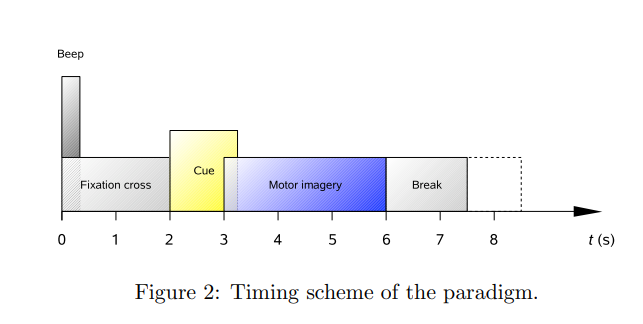

The above is the timing diagram of the experiment. Before the ML pipeline, we shall epoch each of these events, and apply processsing techniques like Common Spatial Pattern (CSP) to obtain numerical features, which will be fed to different classifiers in the pipeline.

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


mne.set_log_level('ERROR')

In [3]:
%matplotlib widget

 ### Section A - Dataset and EDA

 The competition provides two datasets for each subject. In our case there are 9 subject recording, however we shall limit to only using the first subject's data for this track. One dataset is supposed to be trained on fully, and should be tested on the evaluataion dataset.

 ##### A1 - Dataset Loading and Audit

In [4]:
raw_train_1 = mne.io.read_raw_gdf("../datasets/A01T.gdf")
raw_eval_1 = mne.io.read_raw_gdf("../datasets/A01E.gdf")

In [5]:
eog_chs = raw_train_1.ch_names[-3:] 
raw_train_1.set_channel_types({ch: 'eog' for ch in eog_chs})

eog_chs_eval = raw_eval_1.ch_names[-3:]
raw_eval_1.set_channel_types({ch: 'eog' for ch in eog_chs_eval})


ch_names_2a = ['Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz',
               'C2','C4','C6','CP3','CP1','CPz','CP2','CP4','P1','Pz',
               'P2','POz','EOG-left','EOG-central','EOG-right']
raw_train_1.rename_channels(dict(zip(raw_train_1.ch_names, ch_names_2a)))
raw_eval_1.rename_channels(dict(zip(raw_eval_1.ch_names, ch_names_2a)))

raw_train_1.set_montage(mne.channels.make_standard_montage('standard_1020'),
                           match_case=False, on_missing='ignore')
raw_eval_1.set_montage(mne.channels.make_standard_montage('standard_1020'),
                           match_case=False, on_missing='ignore')

<RawGDF | A01E.gdf, 25 x 687000 (2748.0 s), ~33 KiB, data not loaded>

In [6]:
raw_train_1

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~33 KiB, data not loaded>

In [7]:
raw_eval_1

<RawGDF | A01E.gdf, 25 x 687000 (2748.0 s), ~33 KiB, data not loaded>

In [8]:
raw_train_1.load_data()

raw_train_1.notch_filter(freqs=[50, 100], picks='eeg', verbose=False)

raw_train_1.filter(l_freq=1, h_freq=40, picks='eeg', verbose=False)

print("Preprocessing applied:", raw_train_1.info['highpass'], "-", raw_train_1.info['lowpass'], "Hz")
print("Reference:", raw_train_1.info['custom_ref_applied'])

Preprocessing applied: 1.0 - 40.0 Hz
Reference: 0 (FIFFV_MNE_CUSTOM_REF_OFF)


In [9]:
events, event_id = mne.events_from_annotations(raw_train_1, verbose=False)

marker_label = {
    1: "Rejected Trial",
    2: "Eye movments",
    3: "Idling EEG (eyes open)",
    4: "Idling EEG (eyes closed)",
    5: "Start of a new run",
    6: "Start of a trial",
    7: "left_hand",
    8: "right_hand",
    9: "feet",
    10: "tongue",
}

mi_event_id = {marker_label[v]: v for k, v in event_id.items()
               if marker_label[v] in ['left_hand', 'right_hand', 'feet', 'tongue']}

mi_epochs = mne.Epochs(raw_train_1, events, event_id=mi_event_id,
                        tmin=-0.5, tmax=5.25, baseline=None, preload=True)

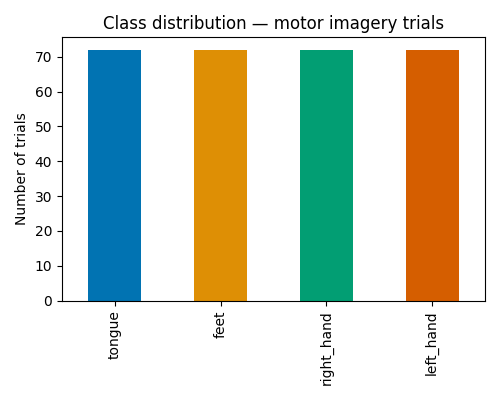

In [10]:
class_counts = pd.Series(mi_epochs.events[:, -1]).map(
    {v: k for k, v in mi_event_id.items()}
).value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
class_counts.plot(kind='bar', ax=ax, color=sns.color_palette('colorblind'))
ax.set_ylabel("Number of trials")
ax.set_title("Class distribution — motor imagery trials")
plt.tight_layout()
plt.show()

> **Insight** We can observe that there is no class imbalance in the train dataset

 ##### A2 - EDA Visualization

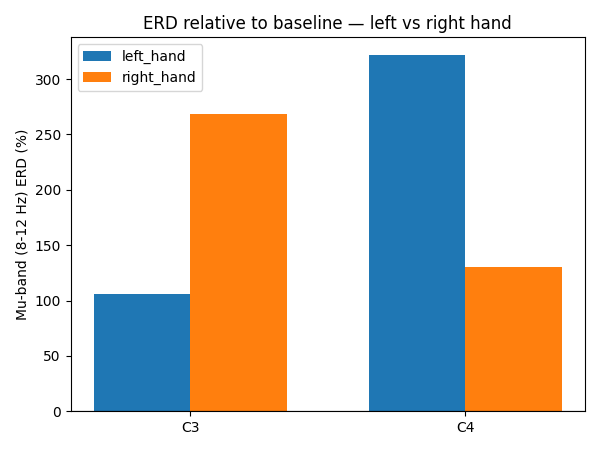

    left_hand_mean_ERD%  right_hand_mean_ERD%
C3           106.271853            268.737933
C4           321.553464            129.821592


In [11]:
def compute_erd_percent(epochs, condition, channel, fmin=8, fmax=12,
                         baseline_window=(-0.5, 0), task_window=(0.5, 4.0)):
    ep = epochs[condition].copy()
    ch_idx = ep.ch_names.index(channel)

    base = ep.copy().crop(*baseline_window)
    task = ep.copy().crop(*task_window)

    psd_base = base.compute_psd(method='welch', fmin=fmin, fmax=fmax,
                                 picks=[ch_idx], verbose=False).get_data().squeeze(axis=1)
    psd_task = task.compute_psd(method='welch', fmin=fmin, fmax=fmax,
                                 picks=[ch_idx], verbose=False).get_data().squeeze(axis=1)

    # mean power per trial across the freq band, then % change vs baseline
    base_power = psd_base.mean(axis=1)
    task_power = psd_task.mean(axis=1)
    erd_pct = 100 * (task_power - base_power) / base_power
    return erd_pct  # one value per trial

fig, ax = plt.subplots(figsize=(6, 4.5))
results = {}
for cls, color in zip(['left_hand', 'right_hand'], ['tab:blue', 'tab:orange']):
    for channel in ['C3', 'C4']:
        erd = compute_erd_percent(mi_epochs, cls, channel)
        results[(cls, channel)] = erd

labels = ['C3', 'C4']
x = np.arange(len(labels))
width = 0.35

left_means = [results[('left_hand', ch)].mean() for ch in labels]
right_means = [results[('right_hand', ch)].mean() for ch in labels]

ax.bar(x - width/2, left_means, width, label='left_hand')
ax.bar(x + width/2, right_means, width, label='right_hand')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mu-band (8-12 Hz) ERD (%)")
ax.set_title("ERD relative to baseline — left vs right hand")
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({f"{cls}_mean_ERD%": [results[(cls, ch)].mean() for ch in labels]
                     for cls in ['left_hand', 'right_hand']}, index=labels))

> **Insight:** Here we see that the left and right target exhbit distinct property in different spatial positions of the brain. With this domain knowledge we can guarantee that there will exist a seperability to train our classifiers

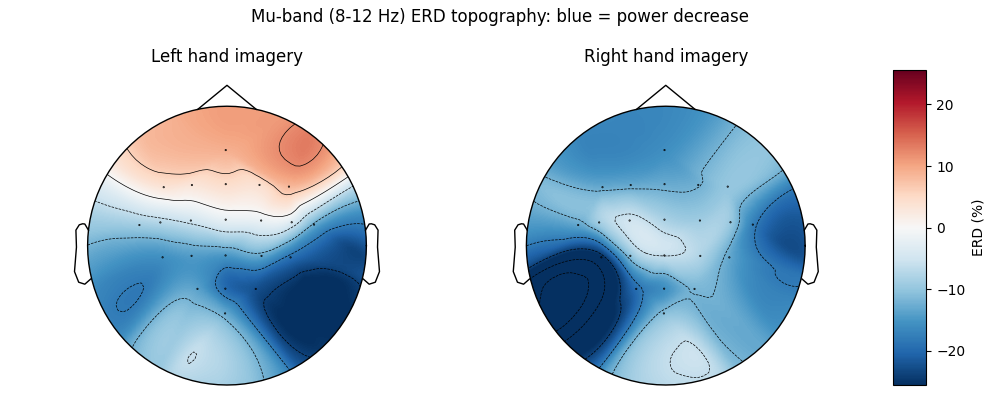

In [12]:
epochs_topo = mi_epochs.copy().pick_types(eeg=True)
montage = mne.channels.make_standard_montage('standard_1020')
epochs_topo.set_montage(montage, match_case=False, on_missing='ignore')

def compute_erd_percent_all_channels(epochs, condition, fmin=8, fmax=12,
                                      baseline_window=(-0.5, 0), task_window=(0.5, 4.0)):
    ep = epochs[condition].copy()
    base = ep.copy().crop(*baseline_window)
    task = ep.copy().crop(*task_window)

    psd_base = base.compute_psd(method='welch', fmin=fmin, fmax=fmax, verbose=False).get_data()
    psd_task = task.compute_psd(method='welch', fmin=fmin, fmax=fmax, verbose=False).get_data()

    base_power = psd_base.mean(axis=2).mean(axis=0)  
    task_power = psd_task.mean(axis=2).mean(axis=0)
    erd_pct = 100 * (task_power - base_power) / base_power
    return erd_pct

erd_left = compute_erd_percent_all_channels(epochs_topo, 'left_hand')
erd_right = compute_erd_percent_all_channels(epochs_topo, 'right_hand')

vlim = max(np.abs(erd_left).max(), np.abs(erd_right).max())

fig, axes = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1, 0.08]})

im, _ = mne.viz.plot_topomap(erd_left, epochs_topo.info, axes=axes[0], show=False,
                              cmap='RdBu_r', vlim=(-vlim, vlim))
axes[0].set_title('Left hand imagery')

im, _ = mne.viz.plot_topomap(erd_right, epochs_topo.info, axes=axes[1], show=False,
                              cmap='RdBu_r', vlim=(-vlim, vlim))
axes[1].set_title('Right hand imagery')

norm = plt.Normalize(vmin=-vlim, vmax=vlim)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
fig.colorbar(sm, cax=axes[2], label='ERD (%)')

fig.suptitle('Mu-band (8-12 Hz) ERD topography: blue = power decrease')
plt.tight_layout()
plt.show()

> **Insight:** This is a visualization of the contralateral ERD/ERS in the motor imagery paradigm. When a left hand movement is imagines, we can observe a decrease in the mu-band power in the right hemisphere. 

 ### Section B - Preprocessing and Feature Engineering

 In this section, we shall see how we derive a tabular dataset from the given time series data. Earlier we had epoched the entire timeseries into 72 epochs for each classes (left, right, foot, tongue). Each of those epochs last for over 7 seconds, sampled at 250Hz. Our goal on the following cells is to convert these time series into a feature vectors. We shall employ CSP. CSP essentially computes the spatial covariance matrices (22 x 22 here) for every point in time in the poch, and averages those covariance matrices.

 Similar to LDA, we find two eigen vectors, maximising one class over minimizing the other class. These eigenvectors are used to project to derive the feature vectors.

 ##### Feature Extraction from Time Series

In [13]:
from mne.decoding import CSP

raw_csp = raw_train_1.copy().filter(l_freq=8, h_freq=30, picks='eeg', verbose=False)
epochs_csp = mne.Epochs(raw_csp, events, event_id=mi_event_id,
                         tmin=-0.5, tmax=5.25, baseline=None, preload=True, verbose=False)
epochs_csp.pick_types(eeg=True)
epochs_csp_crop = epochs_csp.copy().crop(tmin=0.5, tmax=4.0)

X_all = epochs_csp_crop.get_data()      # (n_trials, n_channels, n_times)
y_all = epochs_csp_crop.events[:, -1]   # event codes

class_codes = {cls: mi_event_id[cls] for cls in ['left_hand', 'right_hand', 'feet', 'tongue']}

ovr_features = []
fitted_csps = {}

for cls, code in class_codes.items():
    y_binary = (y_all == code).astype(int)
    csp_cls = CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)
    features = csp_cls.fit_transform(X_all, y_binary)
    ovr_features.append(features)
    fitted_csps[cls] = csp_cls

X_features = np.hstack(ovr_features)  # (n_trials, 16) — 4 classes x 4 components
y_labels = y_all    

feature_names = [f"{cls}_csp{i}" for cls in class_codes for i in range(4)]
df_features = pd.DataFrame(X_features, columns=feature_names)
df_features['label'] = pd.Series(y_labels).map({v: k for k, v in class_codes.items()})

print("CSP feature matrix shape:", X_features.shape)
df_features.head()

CSP feature matrix shape: (288, 16)


,left_hand_csp0,left_hand_csp1,left_hand_csp2,left_hand_csp3,right_hand_csp0,right_hand_csp1,right_hand_csp2,right_hand_csp3,feet_csp0,feet_csp1,feet_csp2,feet_csp3,tongue_csp0,tongue_csp1,tongue_csp2,tongue_csp3,label
0,-0.014977,-0.086175,-0.072868,0.034101,0.213856,-0.001255,-0.016424,-0.083414,-0.427607,-0.489305,-0.398702,-0.385515,-0.234671,-0.471003,-0.452465,-0.378019,tongue
1,0.071896,0.127261,-0.187155,-0.218177,-0.178699,0.010313,0.024996,0.049093,-0.145242,-0.237909,-0.422956,-0.413327,-0.707867,-0.486661,-0.440091,-0.349392,feet
2,-1.208925,-0.911184,-1.663704,-1.799577,-1.875797,-1.505914,-1.169659,-1.084304,-1.075787,-1.774633,-1.468489,-1.931949,-2.216822,-1.693925,-1.937201,-1.408809,right_hand
3,-1.605222,-1.266470,-0.171332,-0.307698,0.033006,-0.057759,-1.616645,-1.177553,-1.554493,-0.890169,-1.379875,-0.389904,-0.548044,-1.201808,-0.781770,-1.537841,left_hand
4,-1.196193,-1.141746,-0.325353,-0.195094,-0.080255,-0.079471,-1.092854,-1.216365,-1.353187,-0.801290,-0.983567,-0.638277,-0.699238,-1.218146,-0.677201,-1.318576,left_hand


##### Visualizing Feature Seperability

> **Insight**: From the below pair plot, we can observe that the four classes attempts to be linearly seperable. For instance in the `right_hand_csp0` and `right_hand_csp2` scatterplot, we can observe the targets clustering. This gives us more confidence in developing our models 

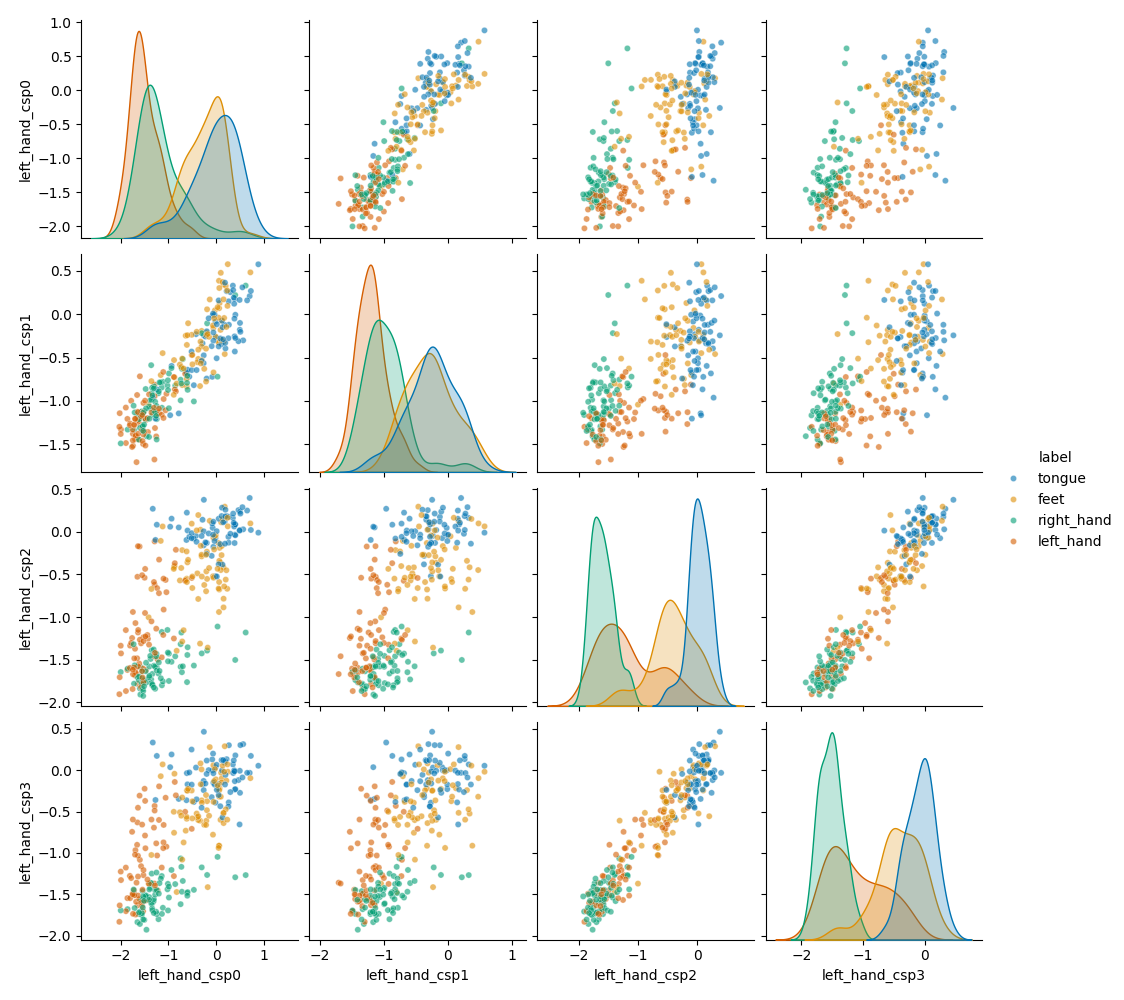

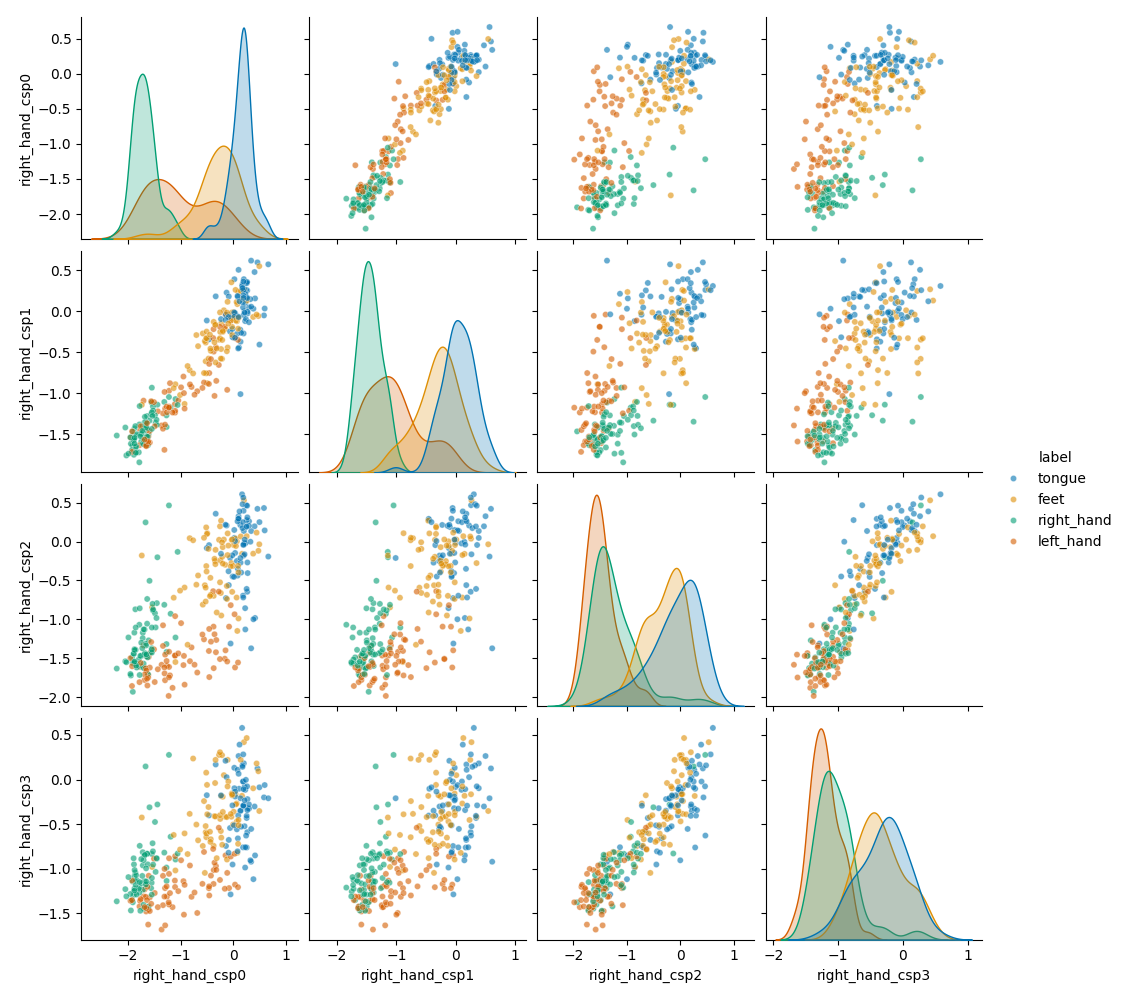

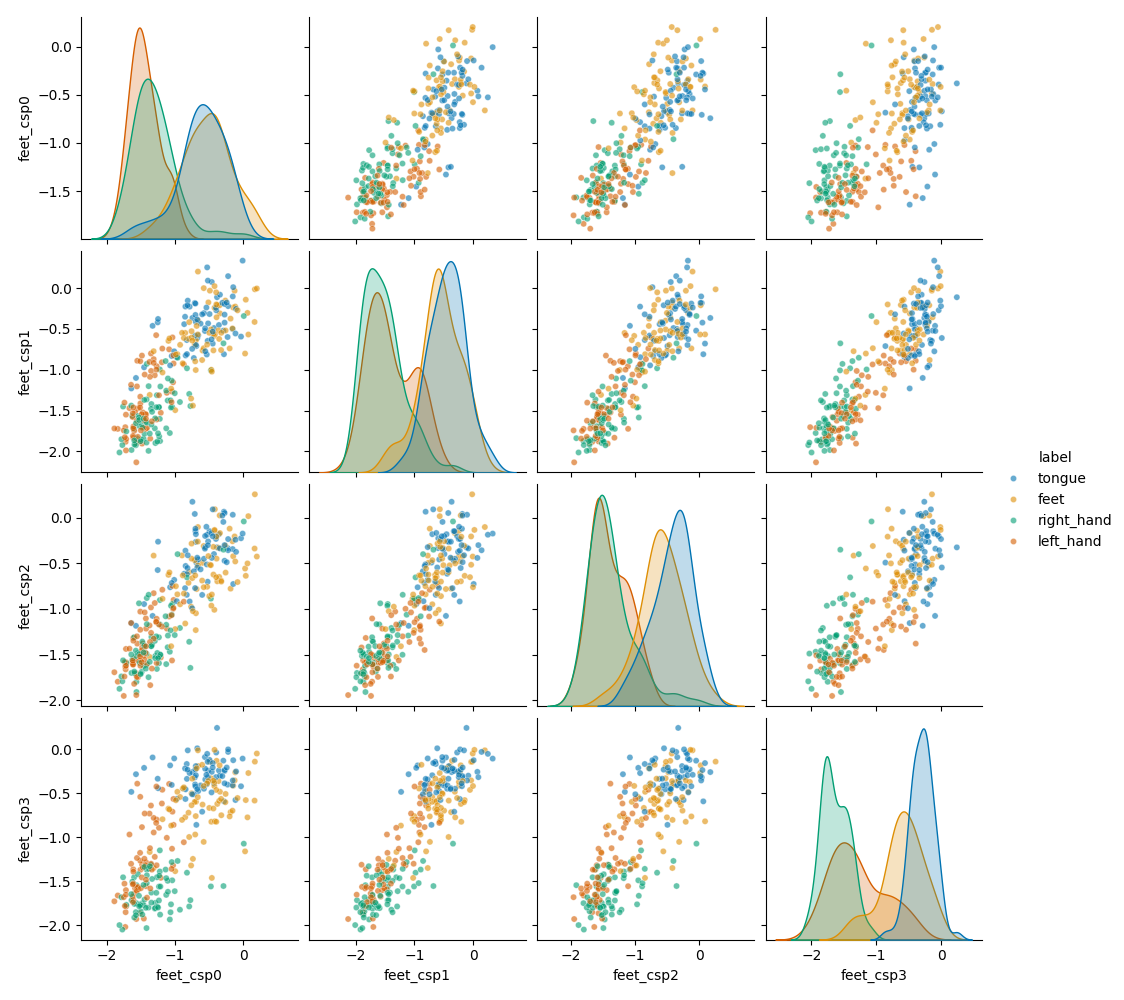

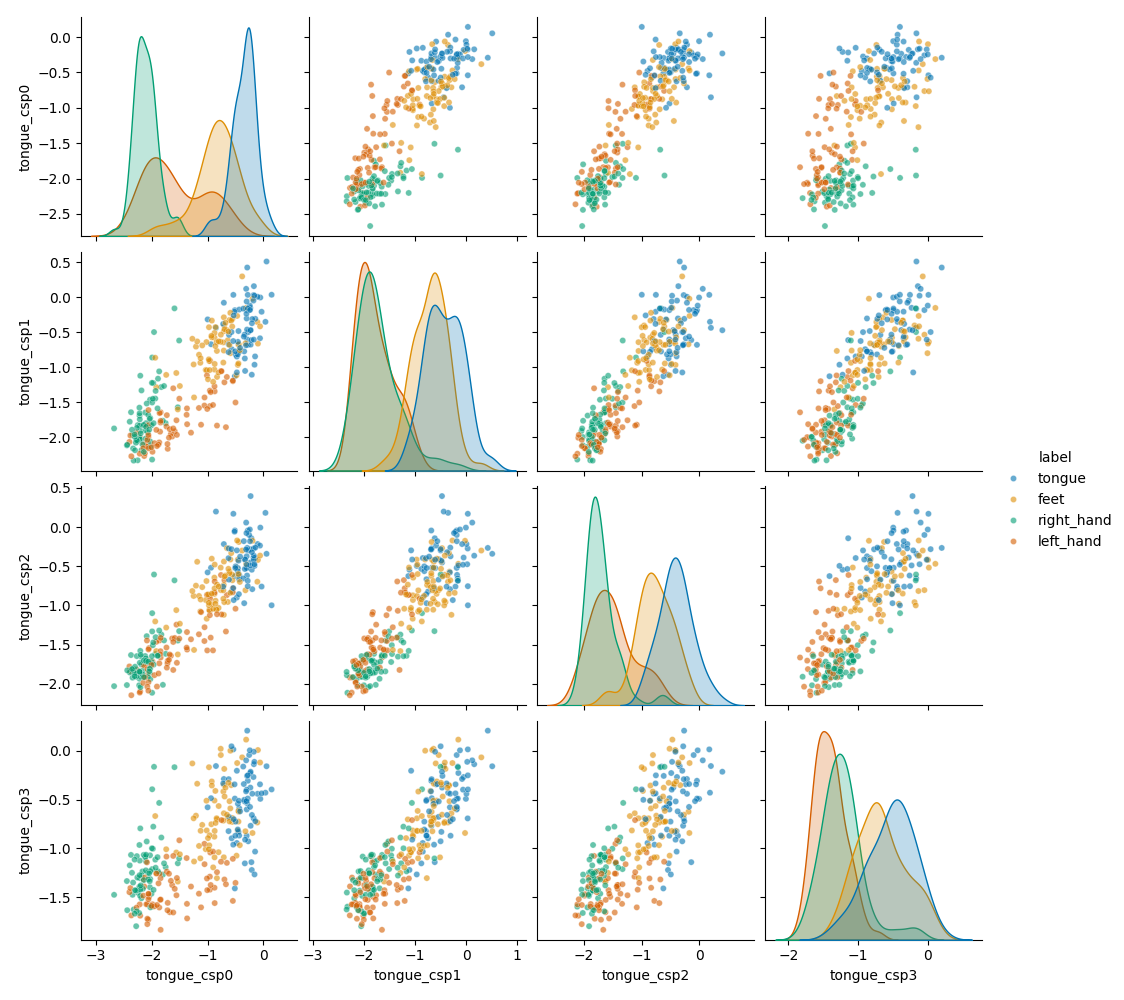

In [14]:
for cls in class_codes.keys():
    cls_features = [f"{cls}_csp{i}" for i in range(4)]
    g = sns.pairplot(df_features, hue='label', vars=cls_features,
                      palette='colorblind', diag_kind='kde',
                      plot_kws={'alpha': 0.6, 's': 20})
    g.fig.suptitle(f'CSP block: {cls} vs rest', y=1.02)
    plt.show()

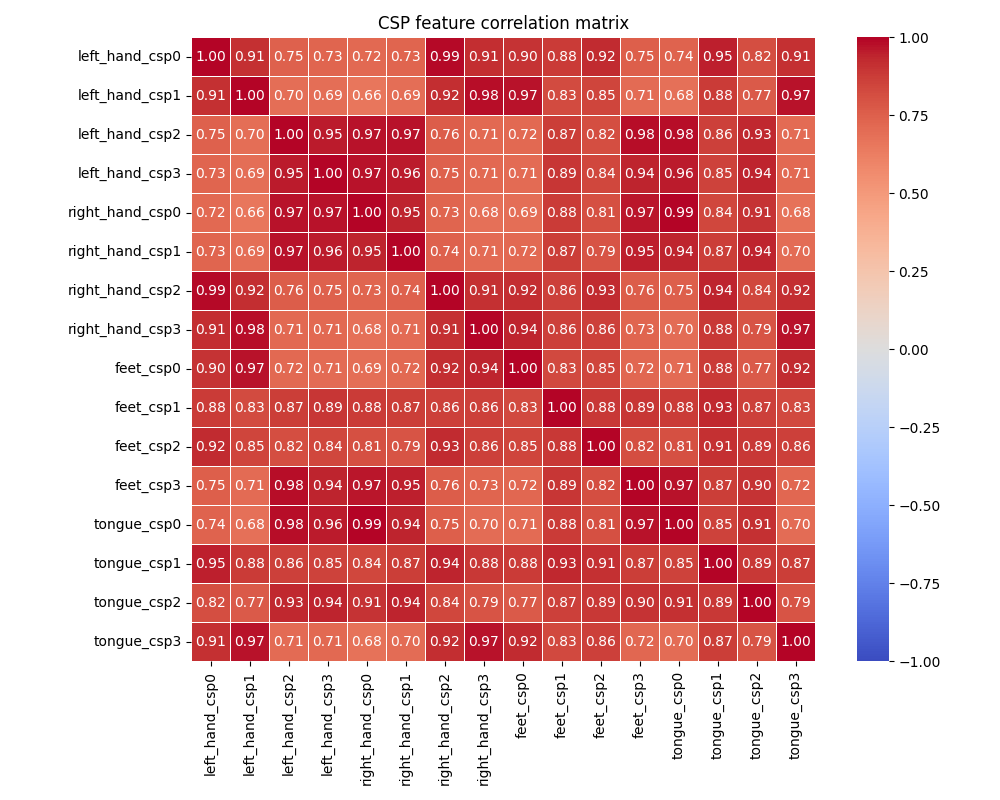

In [15]:
# Compute correlation matrix
corr_matrix = df_features[feature_names].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('CSP feature correlation matrix')
plt.tight_layout()
plt.show()

> **Insight**: Most of the features here are correlated. This doesnt mean that every feature is correlated and the entire dataset is useless. Rather this is an artifact of the spatial locality of the channels. We will later observe that removing correlated features actually reduce model performance

LDA-projected shape: (288, 3)
Explained variance ratio per component: [0.77354392 0.13310712 0.09334896]


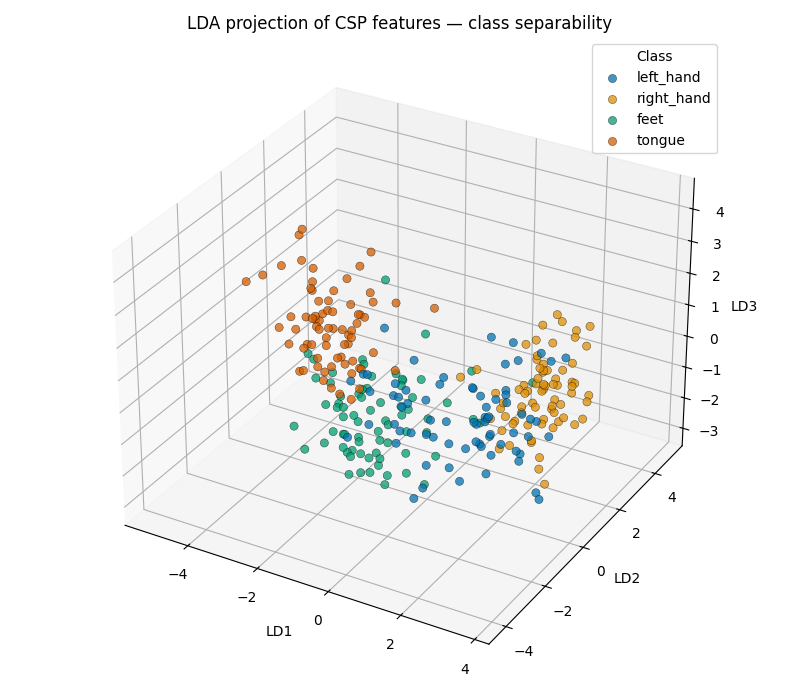

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mpl_toolkits.mplot3d import Axes3D  

lda_viz = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda_viz.fit_transform(X_features, df_features['label'].values)

print("LDA-projected shape:", X_lda.shape)
print("Explained variance ratio per component:", lda_viz.explained_variance_ratio_)

# %%
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

classes = list(class_codes.keys())
palette = sns.color_palette('colorblind', n_colors=len(classes))
color_map = dict(zip(classes, palette))

for cls in classes:
    mask = df_features['label'].values == cls
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], X_lda[mask, 2],
               label=cls, color=color_map[cls], s=35, alpha=0.75, edgecolor='k', linewidth=0.3)

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('LD3')
ax.set_title('LDA projection of CSP features — class separability')
ax.legend(title='Class', loc='best')
plt.tight_layout()
plt.show()

>**Insight**: We attempt to do a dimensional reduction step to understand clearing clustering and seperation of our classes. Since we have 4 classes, we get 4 - 1 = 3 LDA componenets. We plot them in a 3d plot, and we can observe the 4 classes in 4 quadrants of the 3d space.

### D - Implementation of Models

0. LDA

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

clf = LinearDiscriminantAnalysis()
clf.fit(X_features, df_features['label'].values)

cv_scores = cross_val_score(clf, X_features, df_features['label'].values, cv=5)
print(f"Train 5-fold CV accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

Train 5-fold CV accuracy: 0.819 +/- 0.019


1. Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf_logreg = LogisticRegression(max_iter=1000)  # multiclass -> multinomial/softmax automatically
clf_logreg.fit(X_features, df_features['label'].values)

cv_scores_logreg = cross_val_score(clf_logreg, X_features, df_features['label'].values, cv=5)
print(f"LogReg 5-fold CV accuracy: {cv_scores_logreg.mean():.3f} +/- {cv_scores_logreg.std():.3f}")

coef_df = pd.DataFrame(clf_logreg.coef_, columns=feature_names, index=clf_logreg.classes_)
print("\nCoefficients (log-odds contribution per feature, per class):")
print(coef_df.round(3))

odds_df = np.exp(coef_df)
print("\nOdds ratios:")
print(odds_df.round(3))

LogReg 5-fold CV accuracy: 0.833 +/- 0.028

Coefficients (log-odds contribution per feature, per class):
            left_hand_csp0  left_hand_csp1  left_hand_csp2  left_hand_csp3  \
feet                -0.446           0.521           0.065           0.319   
left_hand           -1.413          -0.951          -0.550           0.323   
right_hand           0.805           0.560          -0.684          -1.064   
tongue               1.054          -0.129           1.170           0.422   

            right_hand_csp0  right_hand_csp1  right_hand_csp2  \
feet                 -0.338            0.794           -0.013   
left_hand             1.231           -0.181           -0.732   
right_hand           -1.620           -1.224           -0.038   
tongue                0.727            0.610            0.783   

            right_hand_csp3  feet_csp0  feet_csp1  feet_csp2  feet_csp3  \
feet                  0.533      2.031      0.587      0.647      0.687   
left_hand            -0.712 

##### 2. KNN Classifier

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid_knn = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1)
grid_knn.fit(X_features, df_features['label'].values)

print("Best KNN params:", grid_knn.best_params_)
print(f"Best CV accuracy: {grid_knn.best_score_:.3f}")

clf_knn = grid_knn.best_estimator_

cv_scores_knn = cross_val_score(clf_knn, X_features, df_features['label'].values, cv=5)
print(f"KNN 5-fold CV accuracy: {cv_scores_knn.mean():.3f} +/- {cv_scores_knn.std():.3f}")

c:\Users\akila\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.70822747 0.70822747 0.70169389 0.70822747 0.76739262 0.76739262
 0.76727163 0.74990926 0.77434967 0.77434967 0.78118572 0.77416818
 0.78826376 0.78820327 0.79165154 0.78814277 0.80211736 0.79860859
 0.78838475 0.78820327 0.79183303 0.78487598 0.78844525 0.78493648
 0.7814882  0.77797943 0.78493648 0.7814882  0.7814882  0.78493648
 0.78493648 0.78832426 0.78499698 0.79879008 0.79183303 0.78487598
 0.7814882  0.78838475 0.7954023  0.78487598        nan 0.70834846
        nan 0.70834846        nan 0.76739262        nan 0.77779794
        nan 0.78118572        nan 0.78475499        nan 0.77453116
        nan 0.78832426        nan 0.78838475        nan 0.78832426
        nan 0.78142771        nan 0.78838475        nan 0.78844525
        nan 0.79183303        nan 0.7953418         nan 0.79528131
        nan 0.79885057

Best KNN params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best CV accuracy: 0.802
KNN 5-fold CV accuracy: 0.802 +/- 0.013


##### 3. Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

clf_gnb = GaussianNB()
clf_gnb.fit(X_features, df_features['label'].values)

cv_scores_gnb = cross_val_score(clf_gnb, X_features, df_features['label'].values, cv=5)
print(f"GaussianNB 5-fold CV accuracy: {cv_scores_gnb.mean():.3f} +/- {cv_scores_gnb.std():.3f}")

GaussianNB 5-fold CV accuracy: 0.733 +/- 0.040


##### 4. Decision Tree 

Best max_depth: 4 (CV accuracy 0.716)


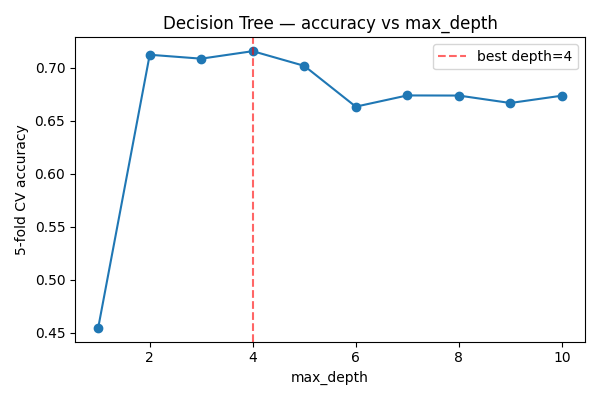

Decision Tree 5-fold CV accuracy: 0.716 +/- 0.072


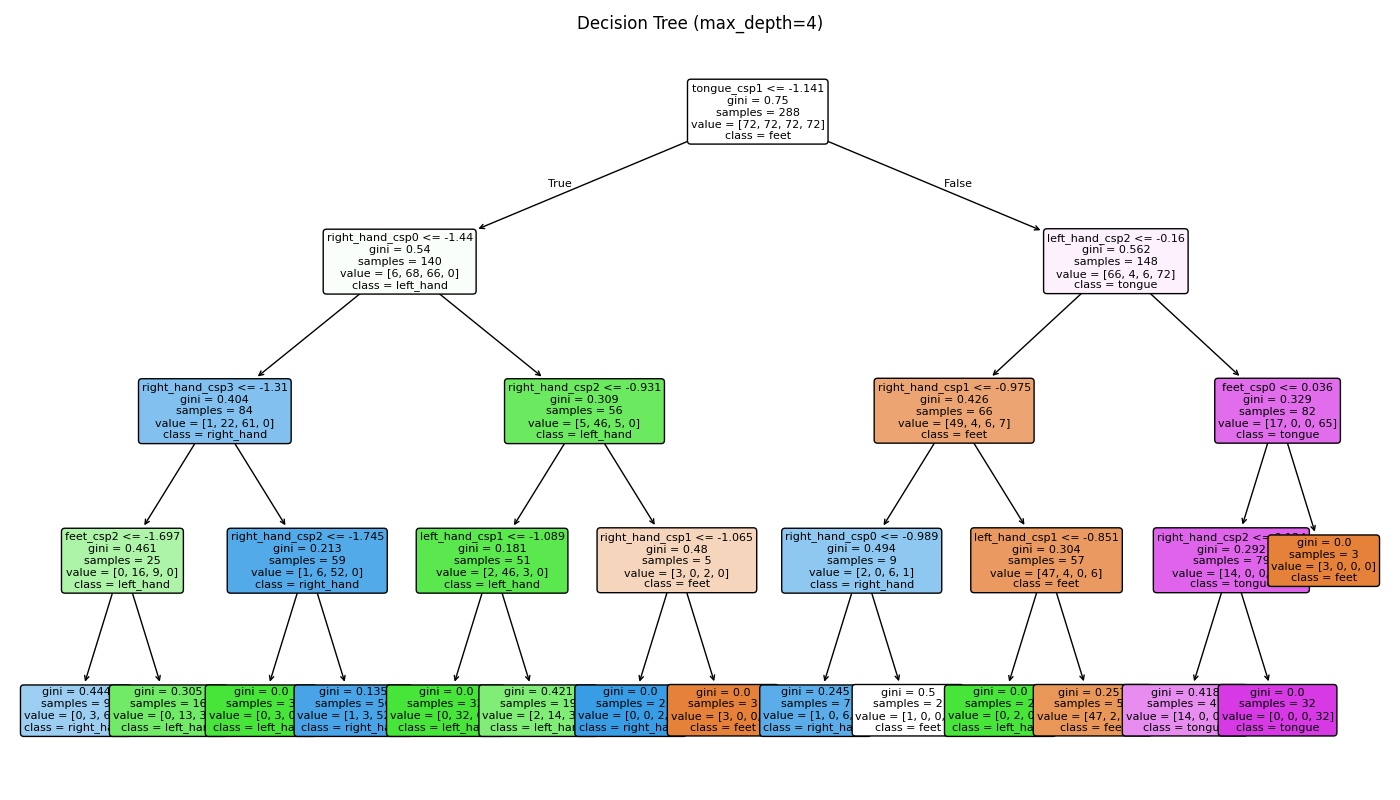

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score


depth_range = range(1, 11)
depth_scores = []
for d in depth_range:
    tree_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(tree_d, X_features, df_features['label'].values, cv=5)
    depth_scores.append(scores.mean())

best_depth = depth_range[int(np.argmax(depth_scores))]
print(f"Best max_depth: {best_depth} (CV accuracy {max(depth_scores):.3f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(depth_range), depth_scores, marker='o')
ax.axvline(best_depth, color='r', linestyle='--', alpha=0.6, label=f'best depth={best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Decision Tree — accuracy vs max_depth')
ax.legend()
plt.tight_layout()
plt.show()

clf_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
clf_tree.fit(X_features, df_features['label'].values)

cv_scores_tree = cross_val_score(clf_tree, X_features, df_features['label'].values, cv=5)
print(f"Decision Tree 5-fold CV accuracy: {cv_scores_tree.mean():.3f} +/- {cv_scores_tree.std():.3f}")

fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(clf_tree, feature_names=feature_names, class_names=clf_tree.classes_,
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title(f"Decision Tree (max_depth={best_depth})")
plt.tight_layout()
plt.show()

##### 5. Support Vector Machine

In [22]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score

param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__kernel': ['linear', 'rbf'],
    'svc__gamma': ['scale', 'auto'],  
}

svm_pipe = make_pipeline(StandardScaler(), SVC())

grid_svm = GridSearchCV(svm_pipe, param_grid, cv=5, n_jobs=-1)
grid_svm.fit(X_features, df_features['label'].values)

print("Best SVM params:", grid_svm.best_params_)
print(f"Best CV accuracy: {grid_svm.best_score_:.3f}")

clf_svm = grid_svm.best_estimator_

cv_scores_svm = cross_val_score(clf_svm, X_features, df_features['label'].values, cv=5)
print(f"SVM 5-fold CV accuracy: {cv_scores_svm.mean():.3f} +/- {cv_scores_svm.std():.3f}")

Best SVM params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
Best CV accuracy: 0.833
SVM 5-fold CV accuracy: 0.833 +/- 0.023


### Section C - Evaluation on the Held-out Eval Set

As mentioned earlier, this is a competition dataset where seperate evaluation datasets with hidden labels were given. Since the competition ended we now have access to the true labels of it. 

Here we first train our model on the entirety of the train data given, and evaluate it on the test data. We follow the similar steps we did earlier for the time series data.

 ##### C1 - Preprocess raw eval dataset

In [23]:
raw_eval_1.load_data()

raw_eval_1.notch_filter(freqs=[50, 100], picks='eeg', verbose=False)
raw_eval_1.filter(l_freq=1, h_freq=40, picks='eeg', verbose=False)

print("Preprocessing applied:", raw_eval_1.info['highpass'], "-", raw_eval_1.info['lowpass'], "Hz")

Preprocessing applied: 1.0 - 40.0 Hz


##### C2 - Epoch the eval data

Unlike the train dataset where each event cue comes with target imagined movement, the eval data only comes with a generic marker which tells the start of an event of some target

In [24]:
events_eval, event_id_eval = mne.events_from_annotations(raw_eval_1, verbose=False)
print("Eval annotation codes found:", event_id_eval)

from collections import Counter
code_counts = Counter(events_eval[:, -1])

cue_desc_eval = '783'

if cue_desc_eval not in event_id_eval:
    raise ValueError(
        f"Expected annotation '783' (unknown cue) in eval file, but only found "
        f"{list(event_id_eval.keys())}. Inspect event_id_eval above and set "
        f"the cue code manually."
    )

cue_code_eval = event_id_eval[cue_desc_eval]
print(f"Eval cue marker: '{cue_desc_eval}' (code {cue_code_eval}) — "
      f"{code_counts[cue_code_eval]} trials")

eval_event_id = {cue_desc_eval: cue_code_eval}

eval_epochs = mne.Epochs(raw_eval_1, events_eval, event_id=eval_event_id,
                          tmin=-0.5, tmax=5.25, baseline=None, preload=True, verbose=False)
eval_epochs

Eval annotation codes found: {np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('783'): 7}
Eval cue marker: '783' (code 7) — 288 trials


<Epochs | 288 events (all good), -0.5 – 5.248 s (baseline off), ~79.0 MiB, data loaded,
 '783': 288>

 ##### C3 - Load true eval labels


In [25]:
from scipy.io import loadmat
import os

true_label_path = "../datasets/A01E.mat"
eval_label_map = {1: 'left_hand', 2: 'right_hand', 3: 'feet', 4: 'tongue'}

if os.path.exists(true_label_path):
    mat = loadmat(true_label_path)
    y_eval_true = mat['classlabel'].ravel()
    y_eval_true_named = pd.Series(y_eval_true).map(eval_label_map).values
    print(f"Loaded {len(y_eval_true_named)} true eval labels from {true_label_path}")
else:
    y_eval_true_named = None
    print(f"No true-label file found at {true_label_path} — "
          f"will show eval predictions only, without an accuracy score.")

Loaded 288 true eval labels from ../datasets/A01E.mat


 ##### C4 - CSP feature extraction on eval epochs (transform only, using the CSPs fitted on train data)

In [26]:
raw_csp_eval = raw_eval_1.copy().filter(l_freq=8, h_freq=30, picks='eeg', verbose=False)
epochs_csp_eval = mne.Epochs(raw_csp_eval, events_eval, event_id=eval_event_id,
                              tmin=-0.5, tmax=5.25, baseline=None, preload=True, verbose=False)
epochs_csp_eval.pick_types(eeg=True)
epochs_csp_eval_crop = epochs_csp_eval.copy().crop(tmin=0.5, tmax=4.0)

X_eval_raw = epochs_csp_eval_crop.get_data()
print("Eval trials tensor shape:", X_eval_raw.shape)

eval_ovr_features = []
for cls, csp_cls in fitted_csps.items():
    feats = csp_cls.transform(X_eval_raw)
    eval_ovr_features.append(feats)

X_eval_features = np.hstack(eval_ovr_features) 
df_eval_features = pd.DataFrame(X_eval_features, columns=feature_names)

print("Eval CSP feature matrix shape:", X_eval_features.shape)
df_eval_features.head()

Eval trials tensor shape: (288, 22, 876)
Eval CSP feature matrix shape: (288, 16)


,left_hand_csp0,left_hand_csp1,left_hand_csp2,left_hand_csp3,right_hand_csp0,right_hand_csp1,right_hand_csp2,right_hand_csp3,feet_csp0,feet_csp1,feet_csp2,feet_csp3,tongue_csp0,tongue_csp1,tongue_csp2,tongue_csp3
0,-0.435196,-0.648686,-0.215029,0.206341,0.200279,0.267265,-0.639313,-0.751519,-0.937290,-0.169498,-1.140579,-0.552332,-0.354362,-0.485695,-0.501197,-1.069163
1,-0.459535,-0.599170,-1.489960,-1.119163,-1.609777,-0.852468,-0.588089,-0.724645,-0.899219,-1.018753,-1.093405,-1.469152,-2.032436,-0.924675,-1.457900,-0.943712
2,-1.424633,-0.960911,-1.287277,-0.737755,-1.010919,-0.674175,-1.328157,-1.205336,-1.149708,-1.324587,-1.239624,-1.523116,-1.608399,-1.564704,-1.218240,-1.359182
3,-1.848227,-1.332504,-0.631122,-0.259794,-0.293820,-0.149385,-1.774188,-1.414843,-1.538214,-0.994525,-1.481998,-0.956163,-0.921737,-1.417063,-0.777668,-1.691819
4,-0.979110,-0.710921,-1.500461,-1.506729,-1.394979,-1.308092,-1.001112,-0.919579,-0.915756,-1.367741,-1.426914,-1.655338,-1.789417,-1.458363,-1.888879,-1.138301


### Benchmarking our models

In [27]:
model_results = {}
class_order = list(class_codes.keys())

##### 0. LDA

Eval accuracy: 0.819

              precision    recall  f1-score   support

        feet       0.84      0.72      0.78        72
   left_hand       0.83      0.86      0.84        72
  right_hand       0.90      0.78      0.84        72
      tongue       0.74      0.92      0.82        72

    accuracy                           0.82       288
   macro avg       0.83      0.82      0.82       288
weighted avg       0.83      0.82      0.82       288



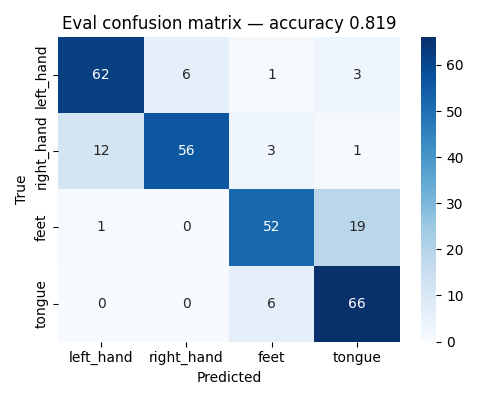

In [28]:
y_eval_pred = clf.predict(X_eval_features)
df_eval_features['predicted_label'] = y_eval_pred

acc = accuracy_score(y_eval_true_named, y_eval_pred)
report_lda = classification_report(y_eval_true_named, y_eval_pred,
                                    labels=class_order, output_dict=True)
print(f"Eval accuracy: {acc:.3f}\n")
print(classification_report(y_eval_true_named, y_eval_pred))

cm = confusion_matrix(y_eval_true_named, y_eval_pred, labels=class_order)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"Eval confusion matrix — accuracy {acc:.3f}")
plt.tight_layout()
plt.show()

model_results['LDA'] = {
    'y_pred': y_eval_pred,
    'accuracy': acc,
    'report': report_lda,
    'confusion_matrix': cm,
}

##### 1. Logistic Regression

Logistic Regression eval accuracy: 0.753

              precision    recall  f1-score   support

        feet       0.80      0.65      0.72        72
   left_hand       0.67      0.96      0.79        72
  right_hand       1.00      0.53      0.69        72
      tongue       0.72      0.88      0.79        72

    accuracy                           0.75       288
   macro avg       0.80      0.75      0.75       288
weighted avg       0.80      0.75      0.75       288



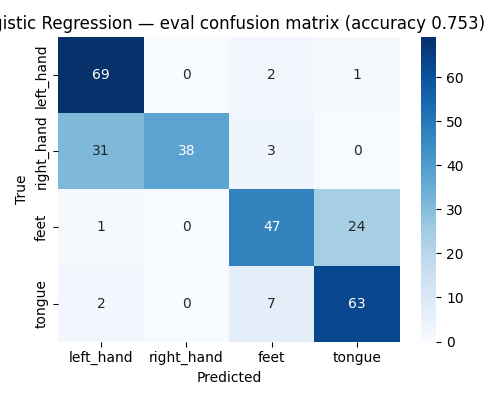

In [29]:
y_pred_logreg = clf_logreg.predict(X_eval_features)
df_eval_features['pred_logreg'] = y_pred_logreg


acc_logreg = accuracy_score(y_eval_true_named, y_pred_logreg)
report_logreg = classification_report(y_eval_true_named, y_pred_logreg,
                                        labels=class_order, output_dict=True)
cm_logreg = confusion_matrix(y_eval_true_named, y_pred_logreg, labels=class_order)

print(f"Logistic Regression eval accuracy: {acc_logreg:.3f}\n")
print(classification_report(y_eval_true_named, y_pred_logreg))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"Logistic Regression — eval confusion matrix (accuracy {acc_logreg:.3f})")
plt.tight_layout()
plt.show()

model_results['Logistic Regression'] = {
    'y_pred': y_pred_logreg,
    'accuracy': acc_logreg,
    'report': report_logreg,
    'confusion_matrix': cm_logreg,
}

##### 2. K-Nearest Neighbor

KNN eval accuracy: 0.708

              precision    recall  f1-score   support

        feet       0.74      0.43      0.54        72
   left_hand       0.68      0.90      0.77        72
  right_hand       0.98      0.60      0.74        72
      tongue       0.61      0.90      0.73        72

    accuracy                           0.71       288
   macro avg       0.75      0.71      0.70       288
weighted avg       0.75      0.71      0.70       288



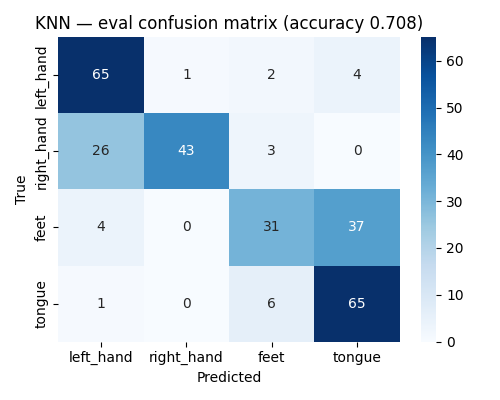

In [30]:
y_pred_knn = clf_knn.predict(X_eval_features)
df_eval_features['pred_knn'] = y_pred_knn

acc_knn = accuracy_score(y_eval_true_named, y_pred_knn)
report_knn = classification_report(y_eval_true_named, y_pred_knn,
                                    labels=class_order, output_dict=True)
cm_knn = confusion_matrix(y_eval_true_named, y_pred_knn, labels=class_order)

print(f"KNN eval accuracy: {acc_knn:.3f}\n")
print(classification_report(y_eval_true_named, y_pred_knn))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"KNN — eval confusion matrix (accuracy {acc_knn:.3f})")
plt.tight_layout()
plt.show()

model_results['KNN'] = {
    'y_pred': y_pred_knn,
    'accuracy': acc_knn,
    'report': report_knn,
    'confusion_matrix': cm_knn,
}

##### 3. Naive Bayes

Gaussian Naive Bayes eval accuracy: 0.688

              precision    recall  f1-score   support

        feet       0.65      0.36      0.46        72
   left_hand       0.79      0.72      0.75        72
  right_hand       0.82      0.75      0.78        72
      tongue       0.57      0.92      0.70        72

    accuracy                           0.69       288
   macro avg       0.71      0.69      0.68       288
weighted avg       0.71      0.69      0.68       288



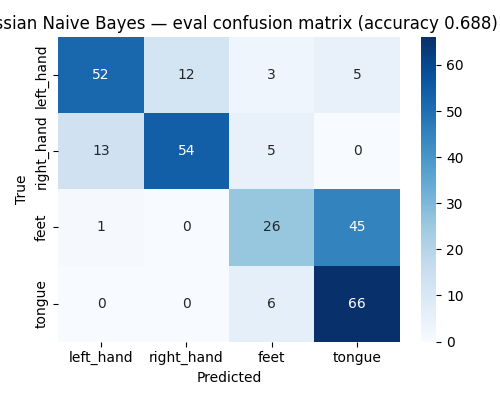

In [31]:
y_pred_gnb = clf_gnb.predict(X_eval_features)
df_eval_features['pred_gnb'] = y_pred_gnb

acc_gnb = accuracy_score(y_eval_true_named, y_pred_gnb)
report_gnb = classification_report(y_eval_true_named, y_pred_gnb,
                                    labels=class_order, output_dict=True)
cm_gnb = confusion_matrix(y_eval_true_named, y_pred_gnb, labels=class_order)

print(f"Gaussian Naive Bayes eval accuracy: {acc_gnb:.3f}\n")
print(classification_report(y_eval_true_named, y_pred_gnb))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"Gaussian Naive Bayes — eval confusion matrix (accuracy {acc_gnb:.3f})")
plt.tight_layout()
plt.show()

model_results['Gaussian Naive Bayes'] = {
    'y_pred': y_pred_gnb,
    'accuracy': acc_gnb,
    'report': report_gnb,
    'confusion_matrix': cm_gnb,
}

##### 4. Decision Tree

Decision Tree eval accuracy: 0.628

              precision    recall  f1-score   support

        feet       0.58      0.58      0.58        72
   left_hand       0.59      0.71      0.65        72
  right_hand       0.74      0.49      0.59        72
      tongue       0.64      0.74      0.68        72

    accuracy                           0.63       288
   macro avg       0.64      0.63      0.63       288
weighted avg       0.64      0.63      0.63       288



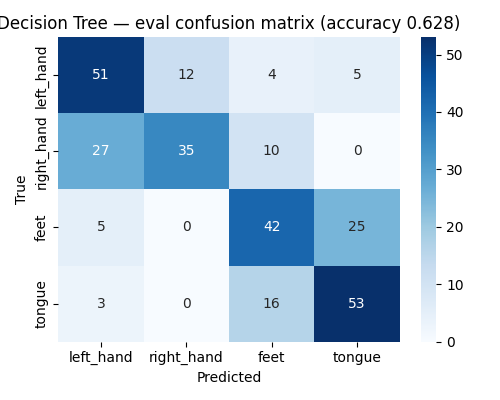

In [32]:
y_pred_tree = clf_tree.predict(X_eval_features)
df_eval_features['pred_tree'] = y_pred_tree

acc_tree = accuracy_score(y_eval_true_named, y_pred_tree)
report_tree = classification_report(y_eval_true_named, y_pred_tree,
                                        labels=class_order, output_dict=True)
cm_tree = confusion_matrix(y_eval_true_named, y_pred_tree, labels=class_order)

print(f"Decision Tree eval accuracy: {acc_tree:.3f}\n")
print(classification_report(y_eval_true_named, y_pred_tree))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"Decision Tree — eval confusion matrix (accuracy {acc_tree:.3f})")
plt.tight_layout()
plt.show()

model_results['Decision Tree'] = {
    'y_pred': y_pred_tree,
    'accuracy': acc_tree,
    'report': report_tree,
    'confusion_matrix': cm_tree,
}

##### 5. SVM

SVM eval accuracy: 0.767

              precision    recall  f1-score   support

        feet       0.80      0.74      0.77        72
   left_hand       0.67      0.92      0.77        72
  right_hand       1.00      0.56      0.71        72
      tongue       0.75      0.86      0.80        72

    accuracy                           0.77       288
   macro avg       0.80      0.77      0.76       288
weighted avg       0.80      0.77      0.76       288



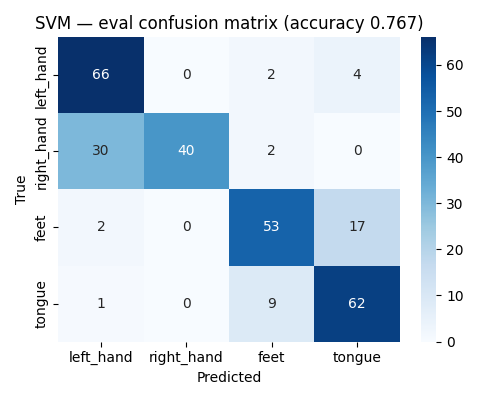

In [33]:
y_pred_svm = clf_svm.predict(X_eval_features)
df_eval_features['pred_svm'] = y_pred_svm

acc_svm = accuracy_score(y_eval_true_named, y_pred_svm)
report_svm = classification_report(y_eval_true_named, y_pred_svm,
                                    labels=class_order, output_dict=True)
cm_svm = confusion_matrix(y_eval_true_named, y_pred_svm, labels=class_order)

print(f"SVM eval accuracy: {acc_svm:.3f}\n")
print(classification_report(y_eval_true_named, y_pred_svm))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f"SVM — eval confusion matrix (accuracy {acc_svm:.3f})")
plt.tight_layout()
plt.show()

model_results['SVM'] = {
    'y_pred': y_pred_svm,
    'accuracy': acc_svm,
    'report': report_svm,
    'confusion_matrix': cm_svm,
}


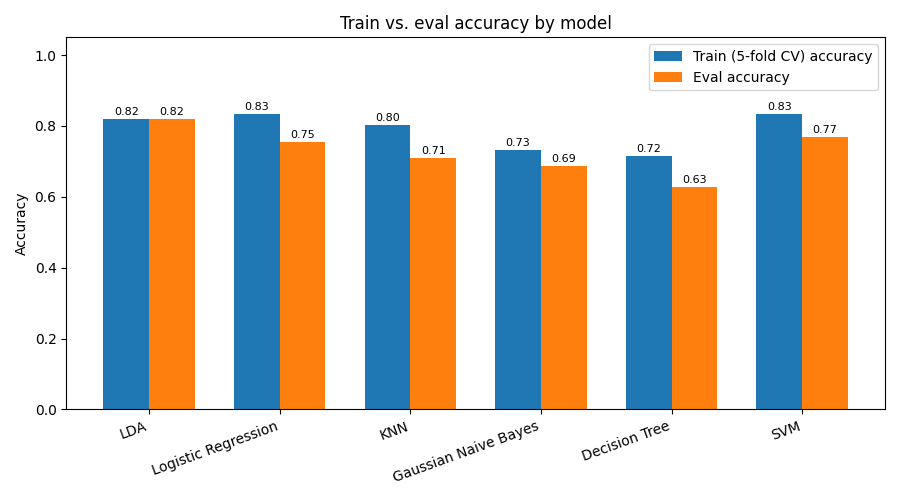

In [34]:
models = list(model_results.keys())

train_accs = [
    cv_scores.mean(),         # LDA
    cv_scores_logreg.mean(),  # Logistic Regression
    cv_scores_knn.mean(),     # KNN
    cv_scores_gnb.mean(),     # Gaussian Naive Bayes
    cv_scores_tree.mean(),    # Decision Tree
    cv_scores_svm.mean(),     # SVM
]

eval_accs = [model_results[m]['accuracy'] for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train (5-fold CV) accuracy', color='tab:blue')
bars2 = ax.bar(x + width/2, eval_accs, width, label='Eval accuracy', color='tab:orange')

ax.set_ylabel('Accuracy')
ax.set_title('Train vs. eval accuracy by model')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()

for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.2f}', xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### Iterations

Now that we are done with a basic visualization, we were interested in the characterisitcs of each model. 
For instance,

1. lda, naive bayes assumes independency between features
2. knns work better with lower dimensional data (curse of dimensionality)

So in the following cells, we remove correlated features and redo the entire pipeline

Threshold: 0.97
Dropped 8 of 16 features:
['right_hand_csp0', 'right_hand_csp1', 'right_hand_csp2', 'right_hand_csp3', 'feet_csp0', 'feet_csp3', 'tongue_csp0', 'tongue_csp3']

Kept 8 features:
['left_hand_csp0', 'left_hand_csp1', 'left_hand_csp2', 'left_hand_csp3', 'feet_csp1', 'feet_csp2', 'tongue_csp1', 'tongue_csp2']


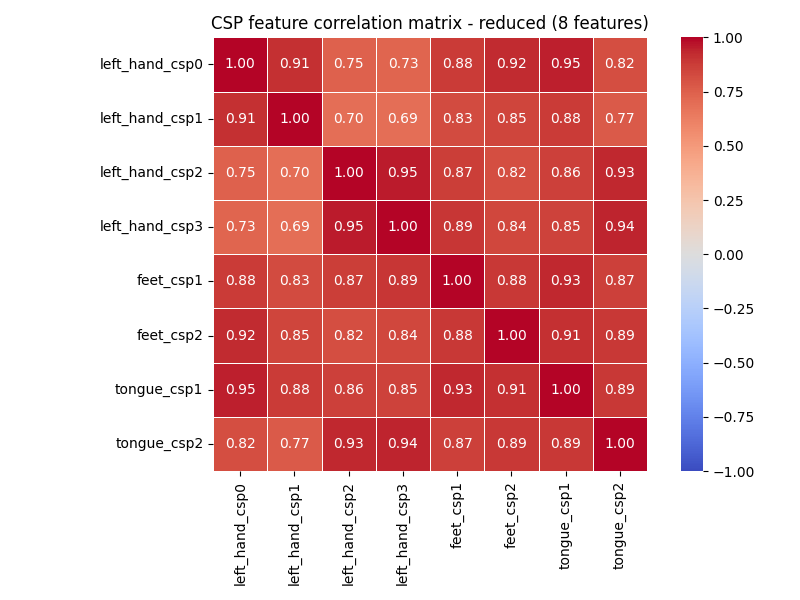

In [35]:
def drop_correlated_features(corr_matrix, threshold=0.9):
    upper = corr_matrix.abs().where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return to_drop

CORR_THRESHOLD = 0.97
dropped_features = drop_correlated_features(corr_matrix, threshold=CORR_THRESHOLD)
kept_features = [f for f in feature_names if f not in dropped_features]

print(f"Threshold: {CORR_THRESHOLD}")
print(f"Dropped {len(dropped_features)} of {len(feature_names)} features:")
print(dropped_features)
print(f"\nKept {len(kept_features)} features:")
print(kept_features)

X_features_reduced = df_features[kept_features].values
X_eval_features_reduced = df_eval_features[kept_features].values


fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_features[kept_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title(f'CSP feature correlation matrix - reduced ({len(kept_features)} features)')
plt.tight_layout()
plt.show()

In [36]:
y_labels_arr = df_features['label'].values
reduced_results = {}
reduced_cv = {}

# 0. LDA
clf_r = LinearDiscriminantAnalysis()
clf_r.fit(X_features_reduced, y_labels_arr)
reduced_cv['LDA'] = cross_val_score(clf_r, X_features_reduced, y_labels_arr, cv=5)

# 1. Logistic Regression
clf_logreg_r = LogisticRegression(max_iter=1000)
clf_logreg_r.fit(X_features_reduced, y_labels_arr)
reduced_cv['Logistic Regression'] = cross_val_score(clf_logreg_r, X_features_reduced, y_labels_arr, cv=5)

# 2. KNN (re-grid-search on reduced features)
grid_knn_r = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, n_jobs=-1)
grid_knn_r.fit(X_features_reduced, y_labels_arr)
clf_knn_r = grid_knn_r.best_estimator_
reduced_cv['KNN'] = cross_val_score(clf_knn_r, X_features_reduced, y_labels_arr, cv=5)
print("Best KNN params (reduced):", grid_knn_r.best_params_)

# 3. Naive Bayes
clf_gnb_r = GaussianNB()
clf_gnb_r.fit(X_features_reduced, y_labels_arr)
reduced_cv['Gaussian Naive Bayes'] = cross_val_score(clf_gnb_r, X_features_reduced, y_labels_arr, cv=5)

# 4. Decision Tree (re-tune depth on reduced features)
depth_scores_r = [
    cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                     X_features_reduced, y_labels_arr, cv=5).mean()
    for d in depth_range
]
best_depth_r = depth_range[int(np.argmax(depth_scores_r))]
clf_tree_r = DecisionTreeClassifier(max_depth=best_depth_r, random_state=42)
clf_tree_r.fit(X_features_reduced, y_labels_arr)
reduced_cv['Decision Tree'] = cross_val_score(clf_tree_r, X_features_reduced, y_labels_arr, cv=5)
print(f"Best max_depth (reduced): {best_depth_r}")

# 5. SVM (re-grid-search on reduced features)
grid_svm_r = GridSearchCV(svm_pipe, param_grid, cv=5, n_jobs=-1)
grid_svm_r.fit(X_features_reduced, y_labels_arr)
clf_svm_r = grid_svm_r.best_estimator_
reduced_cv['SVM'] = cross_val_score(clf_svm_r, X_features_reduced, y_labels_arr, cv=5)
print("Best SVM params (reduced):", grid_svm_r.best_params_)

for name, scores in reduced_cv.items():
    print(f"{name}: {scores.mean():.3f} +/- {scores.std():.3f}")

Best KNN params (reduced): {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Best max_depth (reduced): 5
Best SVM params (reduced): {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
LDA: 0.757 +/- 0.032
Logistic Regression: 0.771 +/- 0.012
KNN: 0.761 +/- 0.042
Gaussian Naive Bayes: 0.698 +/- 0.070
Decision Tree: 0.726 +/- 0.012
SVM: 0.781 +/- 0.017


In [37]:
fitted_reduced = {
    'LDA': clf_r, 'Logistic Regression': clf_logreg_r, 'KNN': clf_knn_r,
    'Gaussian Naive Bayes': clf_gnb_r, 'Decision Tree': clf_tree_r, 'SVM': clf_svm_r,
}

for name, model in fitted_reduced.items():
    y_pred = model.predict(X_eval_features_reduced)
    acc = accuracy_score(y_eval_true_named, y_pred)
    reduced_results[name] = acc
    print(f"{name}: eval accuracy = {acc:.3f}")

LDA: eval accuracy = 0.757
Logistic Regression: eval accuracy = 0.719
KNN: eval accuracy = 0.670
Gaussian Naive Bayes: eval accuracy = 0.639
Decision Tree: eval accuracy = 0.656
SVM: eval accuracy = 0.729


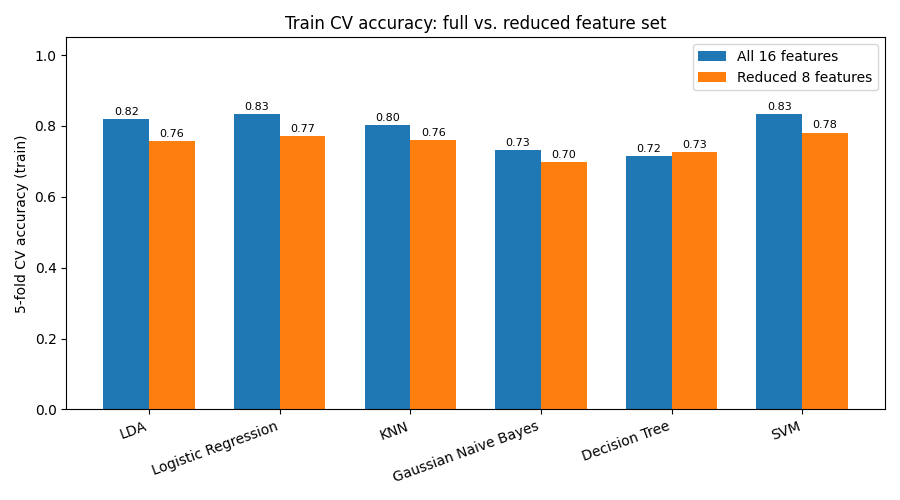

In [38]:
full_feature_train_cv = {
    'LDA': cv_scores.mean(),
    'Logistic Regression': cv_scores_logreg.mean(),
    'KNN': cv_scores_knn.mean(),
    'Gaussian Naive Bayes': cv_scores_gnb.mean(),
    'Decision Tree': cv_scores_tree.mean(),
    'SVM': cv_scores_svm.mean(),
}
reduced_feature_train_cv = {name: scores.mean() for name, scores in reduced_cv.items()}

models_list = list(full_feature_train_cv.keys())
x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [full_feature_train_cv[m] for m in models_list], width,
                label=f'All {len(feature_names)} features')
bars2 = ax.bar(x + width/2, [reduced_feature_train_cv[m] for m in models_list], width,
                label=f'Reduced {len(kept_features)} features')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha='right')
ax.set_ylabel('5-fold CV accuracy (train)')
ax.set_ylim(0, 1.05)
ax.set_title('Train CV accuracy: full vs. reduced feature set')
ax.legend()

for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.2f}', xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


C:\Users\akila\AppData\Local\Temp\ipykernel_28556\800809609.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(9, 5))


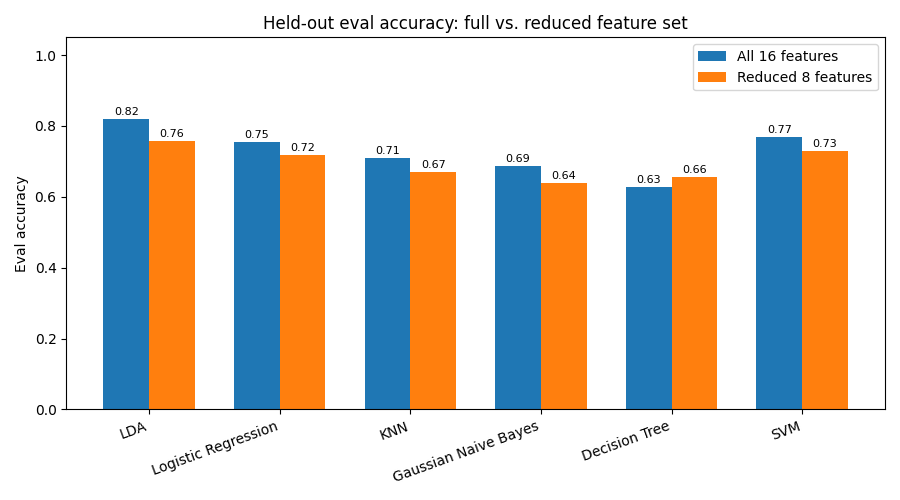

In [39]:
full_feature_eval_acc = {m: model_results[m]['accuracy'] for m in model_results}
reduced_feature_eval_acc = reduced_results  # already {name: acc} from predict() on eval set

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [full_feature_eval_acc[m] for m in models_list], width,
                label=f'All {len(feature_names)} features')
bars2 = ax.bar(x + width/2, [reduced_feature_eval_acc[m] for m in models_list], width,
                label=f'Reduced {len(kept_features)} features')

ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha='right')
ax.set_ylabel('Eval accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Held-out eval accuracy: full vs. reduced feature set')
ax.legend()

for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.2f}', xy=(b.get_x() + b.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

>**Insight**: As we can observe above, the only model which shows a marginal performance increase is the decision tree. We can attribute this to the fact that the decision tree now does less spurious splits because the features are less correlated than what it was before.